# CS 280: Flow Matching

You'll be implementing your own flow matching model with an attention-based UNet. This project was developed by [Jorge Diaz Chao](https://jdiazchao.com), [Jiaxin Ge](https://gejiaxin.org), [Angjoo Kanazawa](https://people.eecs.berkeley.edu/~kanazawa/) and [Alexei A. Efros](https://people.eecs.berkeley.edu/~efros/), and builds on top of the [work](https://cal-cs180.github.io/fa25/hw/proj5/partb.html) of [Tabrizi R.](https://ryantabrizi.com) et al. (2024).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
C, H, W = 1, 32, 32
BATCH_SIZE = 64

### Load the Dataset

We first import the MNIST dataset. As a bonus, you could try other datasets like CIFAR-10 or Celeb-A. We resize images from 28×28 to 32×32, so they work nicely with the ideal flow machines you'll be implementing later in `idealflow.ipynb`.

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


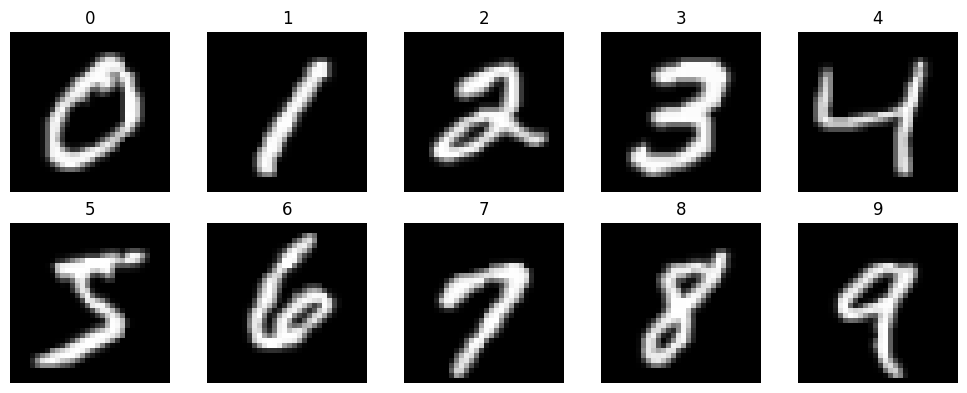

In [4]:
def load_mnist(train=True):
    transform = transforms.Compose([
        transforms.Resize((H, W)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    return torchvision.datasets.MNIST(
        root='../data', train=train, download=True, transform=transform
    )

def denormalize(x):
    return x * 0.5 + 0.5

train_dataset = load_mnist(train=True)
eval_dataset = load_mnist(train=False)
dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

examples = {}
for x, y in train_dataset:
    if y not in examples:
        examples[y] = x
    if len(examples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in zip(range(10), axes.flatten()):
    x = denormalize(examples[digit]).squeeze(0)
    ax.imshow(x, cmap="gray")
    ax.set_title(f"{digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Building the UNet

We'll start off by implementing a denoising UNet, which consists of residual blocks, attention blocks, downsampling and upsampling convolutions with skip connections.

We first implement the residual block (`ResBlock`), a skip-connected convolutional block. The `ResBlock` learns a residual (change) to the features instead of a full transformation, which improves gradient flow, enables deeper networks and preserves low-level information while refining it.

The diagram below shows the `ResBlock` architecture you should implement, the blocks should provide information for what to initialize, while their connections inform how you should construct the forward function.


Conv (a, b, c, d) – `nn.Conv2d(in_channels=a, out_channels=b, kernel_size=c, padding=d)`

G-Norm (a, b) – `nn.GroupNorm(num_groups=a, num_channels=b)`

Silu – `F.silu`

<p align="center">
    <img src="figures/resblock.svg" width="800">
</p>

In [5]:
class ResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor):

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.skip(x)

Then, we implement the attention block (`AttnBlock`), which utilizes self-attention so every token can incorporate global context from the entire feature map. It adds this refinement back through a residual connection for stable learning. Like the `ResBlock`, the diagram below shows how the `AttnBlock` should be constructed.

Attn (a, b) – `nn.MultiheadAttention(embed_dim=a, num_heads=b)`

<p align="center">
    <img src="figures/attnblock.svg" width="450">
</p>

In [6]:
class AttnBlock(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4):
        super().__init__()

        self.norm = nn.GroupNorm(32, channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x: torch.Tensor):

        B, C, H, W = x.shape

        h = self.norm(x)

        h = h.view(B, C, H*W).permute(0, 2, 1)  # B HW C

        h, _ = self.attn(h, h, h)

        h = h.permute(0, 2, 1).view(B, C, H, W)

        return x + h

Following the diagram below, we finalize our first `UNet`. Note that `DownConv` and `UpConv` are different from regular covolutions we utilized in the `ResBlock`, which downsample and upsample the hidden features and are responsible for the U shape of the network.

DownConv (a, b, c, d) – `nn.Conv2d(in_channels=a, out_channels=b, kernel_size=c, stride=2, padding=d)`

UpConv (a, b, c, d) – `nn.Upsample(scale_factor=2)` + `nn.Conv2d(in_channels=a, out_channels=b, kernel_size=c, padding=d)`

ResBlock (a, b) – `ResBlock(in_channels=a, out_channels=b)`

AttnBlock (a, b) – `AttnBlock(channels=a, num_heads=b)`

Cat – `torch.cat`

<p align="center">
    <img src="figures/unet.svg" width="1200">
</p>

In [7]:
class UNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        hidden_dim: int = 32
    ):
        super().__init__()

        # encoder
        self.conv_in = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.res1 = ResBlock(hidden_dim, hidden_dim)
        self.attn1 = AttnBlock(hidden_dim)

        self.down1 = nn.Conv2d(hidden_dim, hidden_dim*2, 3, stride=2, padding=1)

        self.res2 = ResBlock(hidden_dim*2, hidden_dim*2)
        self.attn2 = AttnBlock(hidden_dim*2)

        # bottleneck
        self.res_mid = ResBlock(hidden_dim*2, hidden_dim*2)

        # decoder
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(hidden_dim*2, hidden_dim, 3, padding=1)
        )

        self.res3 = ResBlock(hidden_dim*2, hidden_dim)
        self.attn3 = AttnBlock(hidden_dim)

        self.norm_out = nn.GroupNorm(32, hidden_dim)
        self.conv_out = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)

    def forward(self, x: torch.Tensor):

        x1 = self.conv_in(x)

        x1 = self.res1(x1)
        x1 = self.attn1(x1)

        x2 = self.down1(x1)

        x2 = self.res2(x2)
        x2 = self.attn2(x2)

        x_mid = self.res_mid(x2)

        x = self.up1(x_mid)

        x = torch.cat([x, x1], dim=1)

        x = self.res3(x)
        x = self.attn3(x)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

### Training a Denoising UNet

We aim to solve the following denoising problem, i.e. given a noisy image $x_1$, we aim to train a denoiser $D_\theta$ such that it maps $z$ to a clean image $x$. To do so, we can optimize over an L2 loss

$$
L = \mathbb{E}_{z,x} \| D_\theta(z) - x\|^2.
$$

To train our denoiser, we need to generate training data pairs of $(z, x)$, where each $x$ is a clean MNIST digit. For each training batch, we can produce $z$ from $x$ such that

$$
z = x + \sigma \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, I).
$$

Visualize the different noising processes over $\sigma = \{0.0,\,0.2,\,0.4,\,0.5,\,0.6,\,0.8,\,1.0\}$, assuming normalized $x \in [-1, 1]$.

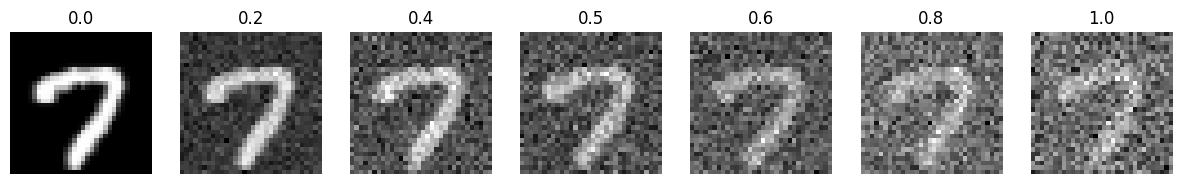

In [10]:
# TODO

sigmas = [0.0,0.2,0.4,0.5,0.6,0.8,1.0]

x,_ = next(iter(dataloader))
x = x[0:1].to(device)

fig,axes = plt.subplots(1,len(sigmas),figsize=(15,3))

for i,s in enumerate(sigmas):

    noise = torch.randn_like(x)
    z = x + s*noise

    img = denormalize(z).cpu().squeeze()

    axes[i].imshow(img,cmap="gray")
    axes[i].set_title(f"{s}")
    axes[i].axis("off")

plt.show()

Now, we'll train our model to perform denoising. Particularly,

- Train a denoiser to denoise noisy image $z$ with $\sigma = 0.5$ applied to a clean image $x$.
- Train on the MNIST training set for 5 or more epochs. Shuffle the dataset before initializing the dataloader. You should add noise to the images after being fetched from the dataloader to improve generalization.
- Your denoiser should be the UNet network you recently implemented with recommended `hidden_dim=32`.
- For the optimizer, utilize `torch.optim.Adam` optimizer with learning rate of $10^{-4}$.

**Deliverables**
- Plot the training loss curve over iterations.
- Show sample denoised results on eval set digits after epochs 1 and 5.

Visualize denoised results on test set digits at the end of epochs 1 and 5.

In [11]:
# TODO

def show_denoise(model,epoch):

    model.eval()

    x,_ = next(iter(eval_dataset))
    x = x.unsqueeze(0).to(device)

    noise = torch.randn_like(x)

    z = x + 0.5*noise

    with torch.no_grad():
      out = model(z)

    fig,axs = plt.subplots(1,3,figsize=(9,3))

    axs[0].imshow(denormalize(x).cpu().squeeze(),cmap="gray")
    axs[0].set_title("clean")

    axs[1].imshow(denormalize(z).cpu().squeeze(),cmap="gray")
    axs[1].set_title("noisy")

    axs[2].imshow(denormalize(out).cpu().squeeze(),cmap="gray")
    axs[2].set_title(f"denoised epoch {epoch}")

    for a in axs:
        a.axis("off")

    plt.show()

100%|██████████| 938/938 [02:53<00:00,  5.39it/s]


epoch 1 loss 0.010823038406670094


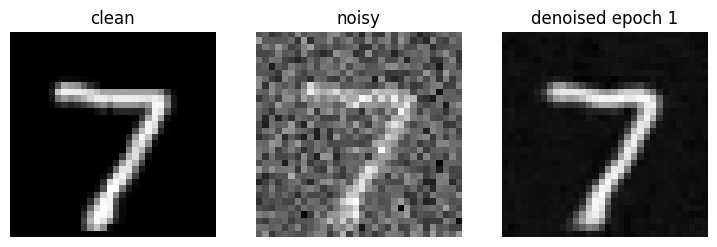

100%|██████████| 938/938 [02:53<00:00,  5.39it/s]


epoch 2 loss 0.009120439179241657


100%|██████████| 938/938 [02:54<00:00,  5.39it/s]


epoch 3 loss 0.009619485586881638


100%|██████████| 938/938 [02:54<00:00,  5.39it/s]


epoch 4 loss 0.008358478546142578


100%|██████████| 938/938 [02:53<00:00,  5.40it/s]


epoch 5 loss 0.008879804983735085


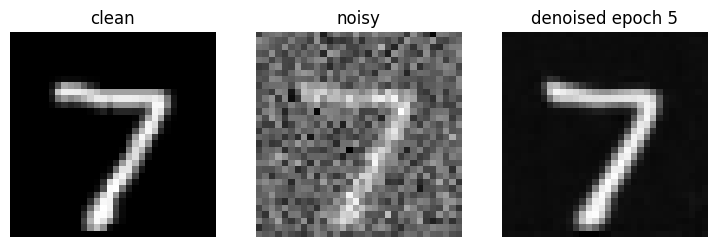

In [13]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)

model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

sigma = 0.5

losses = []

epochs = 5

for epoch in range(epochs):

    for x,_ in tqdm(train_loader):

        x = x.to(device)

        noise = torch.randn_like(x)

        z = x + sigma * noise

        pred = model(z)

        loss = F.mse_loss(pred, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print("epoch",epoch+1,"loss",loss.item())
    if epoch == 0:
      show_denoise(model,1)
    if epoch == 4:
      show_denoise(model,5)

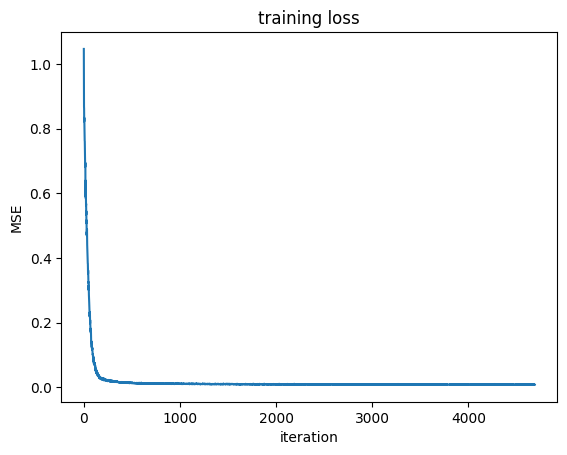

In [14]:
plt.plot(losses)
plt.title("training loss")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.show()

Our denoiser was trained on MNIST digits noised with $\sigma = 0.5$. How would it perform on out-of-distribution noise levels? Visualize the denoiser results on test set digits with $\sigma = \{0.0,\,0.2,\,0.4,\,0.5,\,0.6,\,0.8,\,1.0\}$.

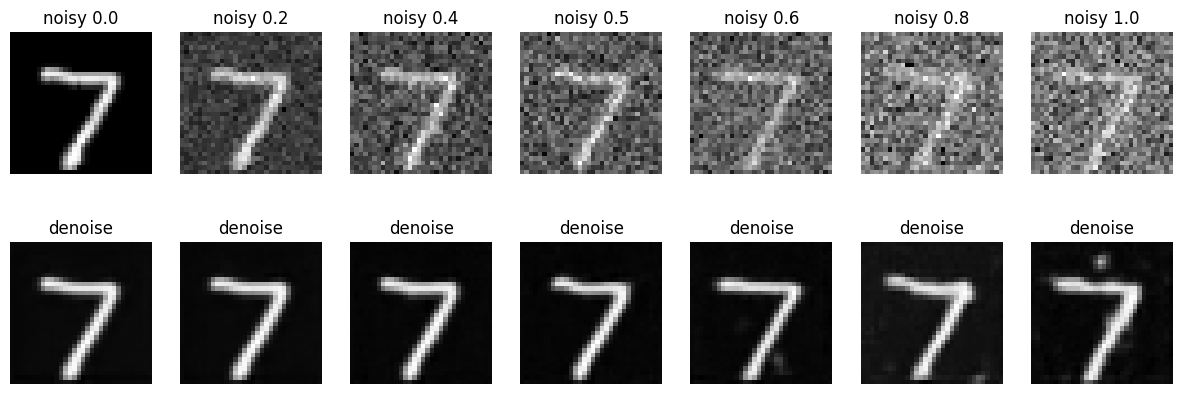

In [15]:
# TODO

sigmas=[0.0,0.2,0.4,0.5,0.6,0.8,1.0]

x,_=next(iter(eval_dataset))
x=x.unsqueeze(0).to(device)

fig,axs=plt.subplots(2,len(sigmas),figsize=(15,5))

for i,s in enumerate(sigmas):

    noise=torch.randn_like(x)
    z=x+s*noise

    with torch.no_grad():
        out=model(z)

    axs[0,i].imshow(denormalize(z).cpu().squeeze(),cmap="gray")
    axs[0,i].set_title(f"noisy {s}")
    axs[0,i].axis("off")

    axs[1,i].imshow(denormalize(out).cpu().squeeze(),cmap="gray")
    axs[1,i].set_title("denoise")
    axs[1,i].axis("off")

plt.show()

In order to make denoising generative, we'd like to be able to denoise pure Gaussian noise. We can think of this as starting with a blank canvas $z = \epsilon$ where $\epsilon \sim \mathcal{N}(0, I)$ and denoising it to get a clean image $x$. We'll first attempt the naive approach, training our network like we just did but start with pure noise $\epsilon \sim \mathcal{N}(0, I)$ instead of a noised digit from the dataset. Again, display results for different epochs.

On top of that, compute the average image of the training set. What do you notice when comparing the average image and our attempts to denoise pure noise? Why would it show such behavior?

In [16]:
def show_pure_noise(model, epoch):

    model.eval()

    z = torch.randn(1, 1, 32, 32).to(device)

    with torch.no_grad():
        out = model(z)

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    axs[0].imshow(denormalize(z).cpu().squeeze(), cmap="gray")
    axs[0].set_title("pure noise")

    axs[1].imshow(denormalize(out).cpu().squeeze(), cmap="gray")
    axs[1].set_title(f"epoch {epoch}")

    for a in axs:
        a.axis("off")

    plt.show()

epoch 1 loss 0.2401: 100%|██████████| 938/938 [02:54<00:00,  5.37it/s]

epoch 1


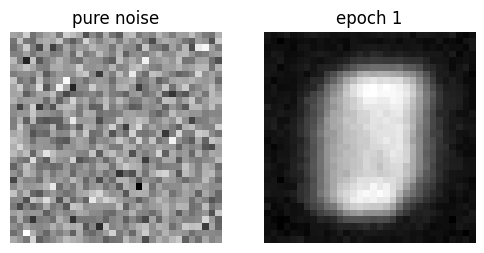

epoch 2 loss 0.2485: 100%|██████████| 938/938 [02:54<00:00,  5.37it/s]


epoch 2


epoch 3 loss 0.2274: 100%|██████████| 938/938 [02:54<00:00,  5.37it/s]


epoch 3


epoch 4 loss 0.2102: 100%|██████████| 938/938 [02:54<00:00,  5.37it/s]


epoch 4


epoch 5 loss 0.2074: 100%|██████████| 938/938 [02:54<00:00,  5.37it/s]

epoch 5


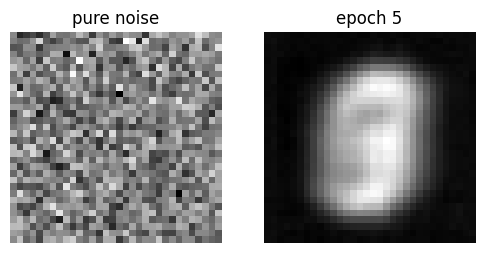

In [18]:
# TODO

from tqdm import tqdm

model_noise = UNet().to(device)

optimizer = torch.optim.Adam(model_noise.parameters(), lr=1e-4)

losses_noise = []

for epoch in range(5):

    pbar = tqdm(train_loader)

    for x, _ in pbar:

        x = x.to(device)

        z = torch.randn_like(x)

        pred = model_noise(z)

        loss = F.mse_loss(pred, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses_noise.append(loss.item())

        pbar.set_description(f"epoch {epoch+1} loss {loss.item():.4f}")

    print("epoch", epoch + 1)
    if epoch == 0:
      show_pure_noise(model_noise,1)
    if epoch == 4:
      show_pure_noise(model_noise,5)

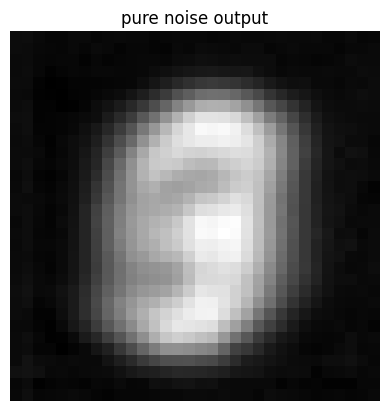

In [19]:
z=torch.randn(1,1,32,32).to(device)

with torch.no_grad():
    out=model_noise(z)

plt.imshow(denormalize(out).cpu().squeeze(),cmap="gray")
plt.title("pure noise output")
plt.axis("off")
plt.show()

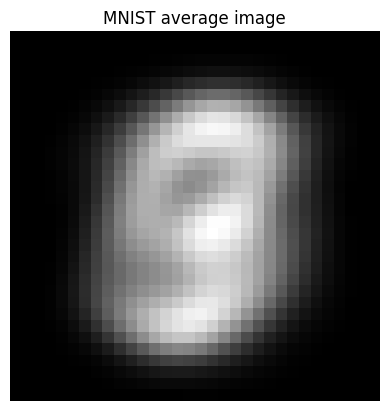

In [20]:
avg=torch.zeros(1,32,32)

for x,_ in train_dataset:
    avg+=x

avg/=len(train_dataset)

plt.imshow(denormalize(avg).squeeze(),cmap="gray")
plt.title("MNIST average image")
plt.axis("off")
plt.show()

The outputs from one step denoising of pure noise resemble the average MNIST image.
This is because the model is trained using an MSE loss, which encourages it to predict
the conditional expectation E[x | z]. When z is pure noise and contains no information
about the original image, the optimal solution is to output the average of all training images.
Therefore, the model produces a blurry average digit instead of meaningful samples.

### Flow Matching

So one-step denoising did not work too well, huh? Instead, one could iteratively denoise the image, and we'll do so with flow matching by training a UNet model to predict the *flow* from our noisy data to clean data. In our flow matching setup, we sample a pure noise image $x_1 \sim \mathcal{N}(0, I)$ and denoise into a valid image $x_0$.

For iterative denoising, we need to define how intermediate noisy samples are constructed. The simplest approach would be a linear interpolation between noisy $x_1$ and clean $x_0$ for some $x_0$ in our training data, such that

$$
x_t = (1 - t)\,x_0 + t\,x_1
\quad \text{where } x_1 \sim \mathcal{N}(0, I), \; t \in [0,1].
$$

Like so, we define a vector field describing the position of a point $x_t$ at time $t$ relative to the clean data distribution and the noisy data distribution. Intuitively, we observe that for large $t$, $x_t$ remains close to noise, while for $t \rightarrow 0$, we approach the clean distribution. Flow can be thought of as the velocity (change in position with respect to time) of such vector field, describing how to move from $x_0$ to $x_1$.

$$
v(x_t, t) = \frac{d}{dt}\,x_t = x_1 - x_0.
$$

So we aim to learn a UNet $v_\theta(x_t, t)$ which approximates this flow $v(x_t, t) = x_1 - x_0$, such that:

$$
L = \mathbb{E}_{x_0 \sim p_0(x_0),\, x_1 \sim p_1(x_1),\, t \sim U[0,1]}
\left\| (x_1 - x_0) - v_\theta(x_t, t) \right\|^2.
$$

Notice that our `UNet` no longer only takes an image-like input like $x_t$, but it's also conditioned on $t$. Before training our flow model we should build on top of our previous `UNet` and `ResBlock` such that they allow for conditioning on $t$. While there are many ways of doing this we suggest doing as the diagram below.

Proj (a, b) – `nn.Linear(in_features=a, out_features=b)`

<p align="center">
    <img src="figures/time_resblock.svg" width="800">
</p>

In [21]:
class ResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, t_dim: int):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.time_proj = nn.Linear(t_dim, out_channels)

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # add time embedding
        t_emb = self.time_proj(t).unsqueeze(-1).unsqueeze(-1)
        h = h + t_emb

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.skip(x)

Now we update our `UNet` to include our time-conditioned `ResBlock`. Note that we should embed the scalar timestep $t$ using sinusoidal positional embeddings with log-spaced frequencies

$$
\omega_k
=
\exp\!\left(
- k \cdot \frac{\log \theta}{\frac{d}{2}-1}
\right),
\quad
k = 0, \dots, \frac{d}{2}-1,
$$

and define

$$
\mathrm{PE}(t)
=
\Big[
\sin(\omega_0 t), \ldots, \sin(\omega_{d/2-1} t),
\cos(\omega_0 t), \ldots, \cos(\omega_{d/2-1} t)
\Big].
$$

This maps $t \in [0,1]$ into a smooth, fixed-dimensional representation that enables the network to condition on different noise levels.

In [22]:
class SinusoidalPositionalEmbeddings(nn.Module):
    def __init__(self, dim: int, theta: float = 10000.0):
        super().__init__()

        self.dim = dim
        self.theta = theta

    def forward(self, x: torch.Tensor):

        device = x.device
        half_dim = self.dim // 2

        k = torch.arange(half_dim, device=device)

        freq = torch.exp(-k * torch.log(torch.tensor(self.theta)) / (half_dim - 1))

        args = x[:, None] * freq[None, :]

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        return emb

class TimeEmbedding(nn.Module):
    def __init__(self, t_dim: int, hidden_dim: int):
        super().__init__()
        self.pos = SinusoidalPositionalEmbeddings(t_dim)
        self.mlp = nn.Sequential(
            nn.Linear(t_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, t_dim)
        )

    def forward(self, t: torch.Tensor):
        t = self.pos(t)
        return self.mlp(t)

TimeEmbed (a, b) – `TimeEmbedding(t_dim=a, hidden_dim=b)`

ResBlock (a, b, c) – `ResBlock(in_channels=a, out_channels=b, t_dim=c)`

<p align="center">
    <img src="figures/time_unet.svg" width="1200">
</p>

In [23]:
class UNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        hidden_dim: int = 32,
        t_dim: int = 64
    ):
        super().__init__()

        self.time_embed = TimeEmbedding(t_dim, hidden_dim)

        self.conv_in = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.res1 = ResBlock(hidden_dim, hidden_dim, t_dim)
        self.attn1 = AttnBlock(hidden_dim)

        self.down = nn.Conv2d(hidden_dim, hidden_dim*2, 3, stride=2, padding=1)

        self.res2 = ResBlock(hidden_dim*2, hidden_dim*2, t_dim)
        self.attn2 = AttnBlock(hidden_dim*2)

        self.mid = ResBlock(hidden_dim*2, hidden_dim*2, t_dim)

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(hidden_dim*2, hidden_dim, 3, padding=1)
        )

        self.res3 = ResBlock(hidden_dim*2, hidden_dim, t_dim)

        self.norm_out = nn.GroupNorm(32, hidden_dim)
        self.conv_out = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor):

        t = self.time_embed(t)

        x1 = self.conv_in(x)
        x1 = self.res1(x1, t)
        x1 = self.attn1(x1)

        x2 = self.down(x1)
        x2 = self.res2(x2, t)
        x2 = self.attn2(x2)

        mid = self.mid(x2, t)

        x = self.up(mid)

        x = torch.cat([x, x1], dim=1)

        x = self.res3(x, t)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

Now you should implement the following

`FlowMatching.loss` – (1) takes a clean image $x_0$, (2) samples noise and a time $t$, (3) produces $x_t=(1 - t)\,x_0 + t\,x_1$ via interpolation and target velocity $v = x_1 - x_0.$ and (4) returns the mean squared error (MSE) loss between the model's predicted velocity and the target velocity.

`FlowMatching.sample` – (1) initializes $x_t$ as noise or $x_1$ if provided, (2) denoises $x_t$ iteratively for `num_inference_steps` $T$ via $x_t \leftarrow x_t-\frac{1}{T} \hat{v}$ and (3) returns the final denoised image.

In [24]:
class FlowMatching(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    def loss(self, x_0: torch.Tensor):

        B = x_0.shape[0]

        x_1 = torch.randn_like(x_0)

        t = torch.rand(B, device=x_0.device)

        t_view = t.view(B,1,1,1)

        x_t = (1 - t_view) * x_0 + t_view * x_1

        v = x_1 - x_0

        v_pred = self.model(x_t, t)

        loss = F.mse_loss(v_pred, v)

        return loss

    @torch.no_grad()
    def sample(self, size=None, x_1=None, num_inference_steps=50, device=None):

        if x_1 is None:
            x = torch.randn(size).to(device)
        else:
            x = x_1.to(device)

        B = x.shape[0]

        for i in tqdm(range(num_inference_steps)):

            t = torch.ones(B, device=device) * (1 - i/num_inference_steps)

            v = self.model(x, t)

            x = x - v / num_inference_steps

        return x

Train the time-conditioned flow matching model.

- Use `hidden_dim=32` and `t_dim=64`, and train for 10 epochs.
- Use `torch.optim.Adam` with learning rate $10^{-3}$.

**Deliverables:**
- Plot the training loss curve over all iterations.
- Show sampling results after epochs 5 and 10.

In [25]:
from torch.utils.data import Subset

def show_samples(flow, n=16):

    torch.manual_seed(0)

    samples = flow.sample(
        size=(n,1,32,32),
        num_inference_steps=50,
        device=device
    )

    samples = denormalize(samples).cpu()

    fig,axs = plt.subplots(4,4,figsize=(6,6))

    for i,ax in enumerate(axs.flatten()):
        ax.imshow(samples[i].squeeze(), cmap="gray")
        ax.axis("off")

    plt.show()

Visualize generated samples from your trained flow matching model. Display results after epochs 5 and 10.

epoch 1 loss 0.19046026468276978
Sampling epoch 1


100%|██████████| 50/50 [00:00<00:00, 137.14it/s]


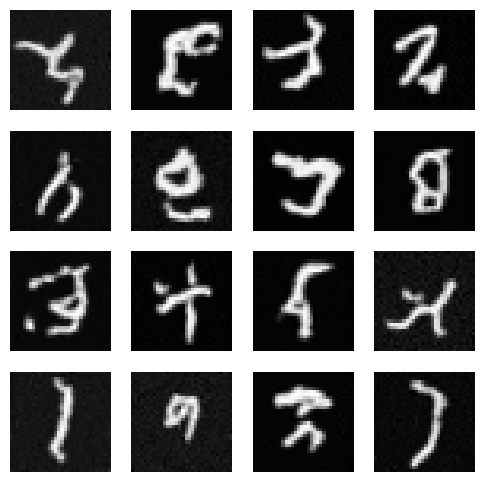

epoch 2 loss 0.17223739624023438
Sampling epoch 2
epoch 3 loss 0.15933343768119812
Sampling epoch 3
epoch 4 loss 0.14125287532806396
Sampling epoch 4
epoch 5 loss 0.1506328582763672
Sampling epoch 5


100%|██████████| 50/50 [00:00<00:00, 148.13it/s]


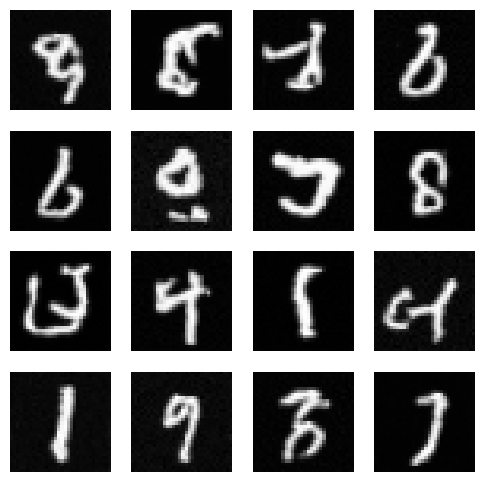

epoch 6 loss 0.15285097062587738
Sampling epoch 6
epoch 7 loss 0.15102100372314453
Sampling epoch 7
epoch 8 loss 0.13432279229164124
Sampling epoch 8
epoch 9 loss 0.1483834683895111
Sampling epoch 9
epoch 10 loss 0.127113938331604
Sampling epoch 10


100%|██████████| 50/50 [00:00<00:00, 148.62it/s]


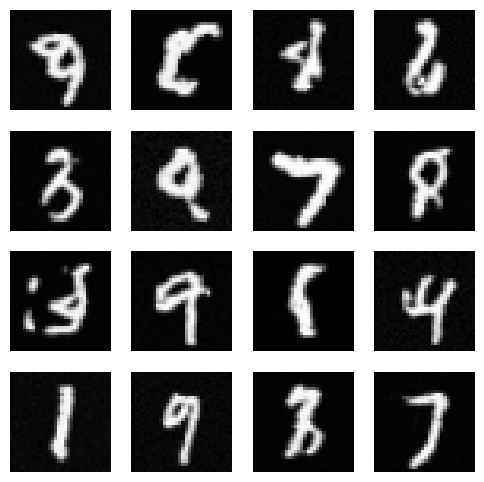

In [26]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


model = UNet(in_channels=1, hidden_dim=32, t_dim=64).to(device)

flow = FlowMatching(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
losses = []

for epoch in range(epochs):

    model.train()

    for x,_ in train_loader:

        x = x.to(device)

        loss = flow.loss(x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print("epoch",epoch+1,"loss",loss.item())
    print("Sampling epoch",epoch+1)
    if epoch+1 == 1:
      show_samples(flow)

    if epoch+1 == 5:
      show_samples(flow)

    if epoch+1 == 10:
      show_samples(flow)

torch.save(model.state_dict(), "unet_flow_matching.pt")

In [27]:
from google.colab import files
torch.save(model.state_dict(), "unet_flow_matching.pt")
files.download("unet_flow_matching.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

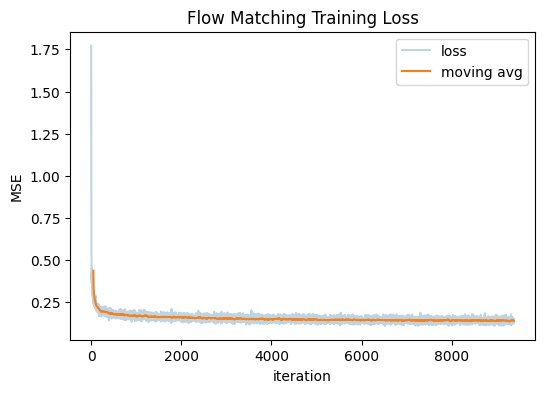

In [28]:
import numpy as np

plt.figure(figsize=(6,4))

# raw loss
plt.plot(losses, alpha=0.3, label="loss")

# moving average
window = 50
smooth = np.convolve(losses, np.ones(window)/window, mode="valid")

plt.plot(range(window-1, len(losses)), smooth, label="moving avg")

plt.title("Flow Matching Training Loss")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.legend()

plt.show()

### Class-Conditioned Flow Matching

By now, you should have a not-so-effective, but working, ten-sided die. How could we condition it so we could choose which number to generate?

There are numerous ways one could go about it. We could modify our `ResBlock` to be conditioned on both time and class as the diagram below depicts.

<p align="center">
    <img src="figures/class_resblock.svg" width="800">
</p>

In [30]:
class ResBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_dim, cls_dim=None):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.time_proj = nn.Linear(t_dim, out_channels)

        if cls_dim is not None:
            self.cls_proj = nn.Linear(cls_dim, out_channels)
        else:
            self.cls_proj = None

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t, cls=None):

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # time embedding
        t_emb = self.time_proj(t).unsqueeze(-1).unsqueeze(-1)
        h = h + t_emb

        # class embedding
        if cls is not None and self.cls_proj is not None:
            c_emb = self.cls_proj(cls).unsqueeze(-1).unsqueeze(-1)
            h = h + c_emb

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.skip(x)

ClsEmbed (a, b) – `nn.Embedding(num_embeddings=a, embedding_dim=b)`

ResBlock (a, b, c, d) – `ResBlock(in_channels=a, out_channels=b, t_dim=c, cls_dim=d)`

<p align="center">
    <img src="figures/class_unet.svg" width="1200">
</p>

In [31]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=1,
        hidden_dim=32,
        t_dim=64,
        cls_dim=64,
        num_classes=10
    ):
        super().__init__()

        self.time_embed = TimeEmbedding(t_dim, hidden_dim)

        self.cls_embed = nn.Embedding(num_classes, cls_dim)

        self.conv_in = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.res1 = ResBlock(hidden_dim, hidden_dim, t_dim, cls_dim)
        self.attn1 = AttnBlock(hidden_dim)

        self.down = nn.Conv2d(hidden_dim, hidden_dim*2, 3, stride=2, padding=1)

        self.res2 = ResBlock(hidden_dim*2, hidden_dim*2, t_dim, cls_dim)
        self.attn2 = AttnBlock(hidden_dim*2)

        self.mid = ResBlock(hidden_dim*2, hidden_dim*2, t_dim, cls_dim)

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(hidden_dim*2, hidden_dim, 3, padding=1)
        )

        self.res3 = ResBlock(hidden_dim*2, hidden_dim, t_dim, cls_dim)

        self.norm_out = nn.GroupNorm(32, hidden_dim)
        self.conv_out = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)

    def forward(self, x, t, cls=None):

        t = self.time_embed(t)

        if cls is not None:
            cls = self.cls_embed(cls)

        x1 = self.conv_in(x)
        x1 = self.res1(x1, t, cls)
        x1 = self.attn1(x1)

        x2 = self.down(x1)
        x2 = self.res2(x2, t, cls)
        x2 = self.attn2(x2)

        mid = self.mid(x2, t, cls)

        x = self.up(mid)

        x = torch.cat([x, x1], dim=1)

        x = self.res3(x, t, cls)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

To enable classifier-free guidance (CFG), during training we randomly drop the class conditioning with probability $p_\text{uncond} = 0.1$ such that we input a null conditioning signal. At sampling time, we compute both a conditional and unconditional velocity estimate and blend them:

$$
\hat{v} = v_\theta(x_t, t, \varnothing) + \gamma \left( v_\theta(x_t, t, c) - v_\theta(x_t, t, \varnothing) \right)
$$

where $\gamma$ is the guidance scale. You should extend your `FlowMatching` class (or write a new one) to support class-conditioned training with unconditional dropout, and CFG-guided sampling.

In [32]:
class FlowMatchingCFG(nn.Module):

    def __init__(self, model, p_uncond=0.1):
        super().__init__()
        self.model = model
        self.p_uncond = p_uncond

    def loss(self, x_0, cls):

        B = x_0.shape[0]

        x_1 = torch.randn_like(x_0)

        t = torch.rand(B, device=x_0.device)

        t_view = t.view(B,1,1,1)

        x_t = (1 - t_view) * x_0 + t_view * x_1

        v = x_1 - x_0

        mask = torch.rand(B, device=x_0.device) < self.p_uncond
        cls_input = cls.clone()
        cls_input[mask] = 0

        v_pred = self.model(x_t, t, cls_input)

        return F.mse_loss(v_pred, v)

    @torch.no_grad()
    def sample(self, classes, gamma=5.0, num_steps=50, device=None):

        B = len(classes)

        x = torch.randn(B,1,32,32).to(device)

        classes = classes.to(device)

        for i in range(num_steps):

            t = torch.ones(B,device=device)*(1-i/num_steps)

            v_uncond = self.model(x, t, None)

            v_cond = self.model(x, t, classes)

            v = v_uncond + gamma * (v_cond - v_uncond)

            x = x - v/num_steps

        return x

Train the class-conditioned flow matching model.

- Use `hidden_dim=32`, `t_dim=64`, `cls_dim=64` and train for 10 epochs.
- Use `torch.optim.Adam` with learning rate $10^{-3}$.
- During training, drop the class label with probability $p_\text{uncond} = 0.1$.

**Deliverables:**
- Plot the training loss curve.
- Show sampling results after epochs 5 and 10.

In [33]:
def sample_grid(flow, gamma=5.0):

    classes = []

    for i in range(10):
        classes += [i]*4

    classes = torch.tensor(classes)

    samples = flow.sample(classes, gamma=gamma, device=device)

    samples = denormalize(samples).cpu()

    fig,axs = plt.subplots(10,4,figsize=(6,12))

    idx=0

    for i in range(10):
        for j in range(4):

            axs[i,j].imshow(samples[idx].squeeze(), cmap="gray")
            axs[i,j].axis("off")

            if j==0:
                axs[i,j].set_ylabel(str(i))

            idx+=1

    plt.tight_layout()
    plt.show()

In [33]:
# subset = torch.utils.data.Subset(train_dataset, range(2000))
# train_loader = DataLoader(subset, batch_size=64, shuffle=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Sample from the class-conditioned model using classifier-free guidance with $\gamma = 5.0$. Generate 4 images per digit class (0–9) and display them in a grid.

**Deliverables:**
- A 10×4 grid of class-conditioned samples after epochs 5 and 10.

epoch 1 loss 0.1584: 100%|██████████| 938/938 [01:42<00:00,  9.15it/s]


epoch 1 loss 0.16520953178405762
sampling epoch 1


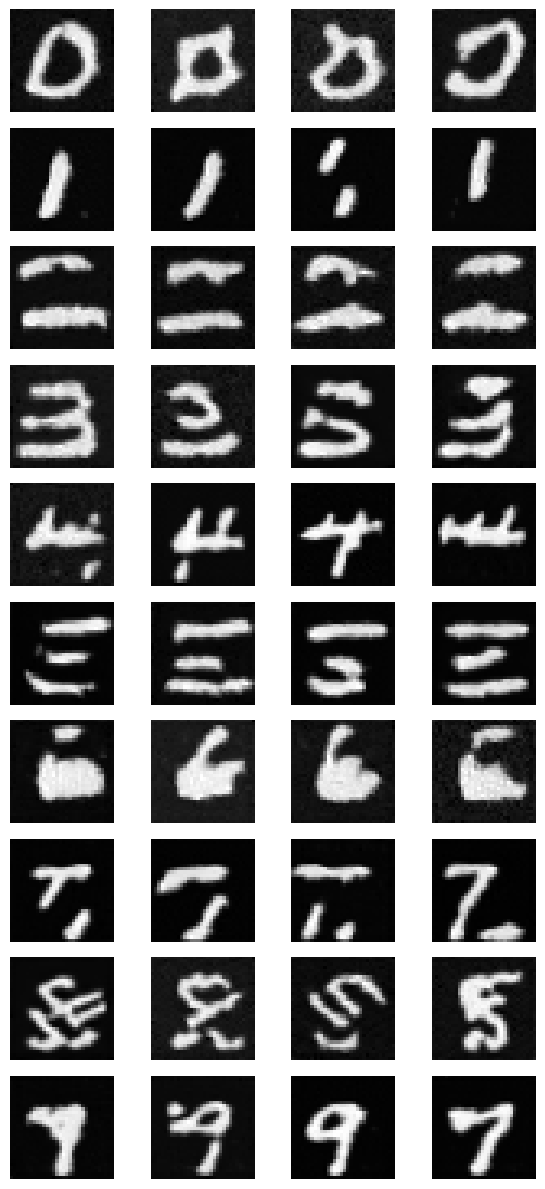

epoch 2 loss 0.1488: 100%|██████████| 938/938 [01:42<00:00,  9.16it/s]


epoch 2 loss 0.15391096472740173
sampling epoch 2


epoch 3 loss 0.1425: 100%|██████████| 938/938 [01:42<00:00,  9.16it/s]


epoch 3 loss 0.14492034912109375
sampling epoch 3


epoch 4 loss 0.1377: 100%|██████████| 938/938 [01:42<00:00,  9.16it/s]


epoch 4 loss 0.11281366646289825
sampling epoch 4


epoch 5 loss 0.1354: 100%|██████████| 938/938 [01:42<00:00,  9.16it/s]


epoch 5 loss 0.16477932035923004
sampling epoch 5


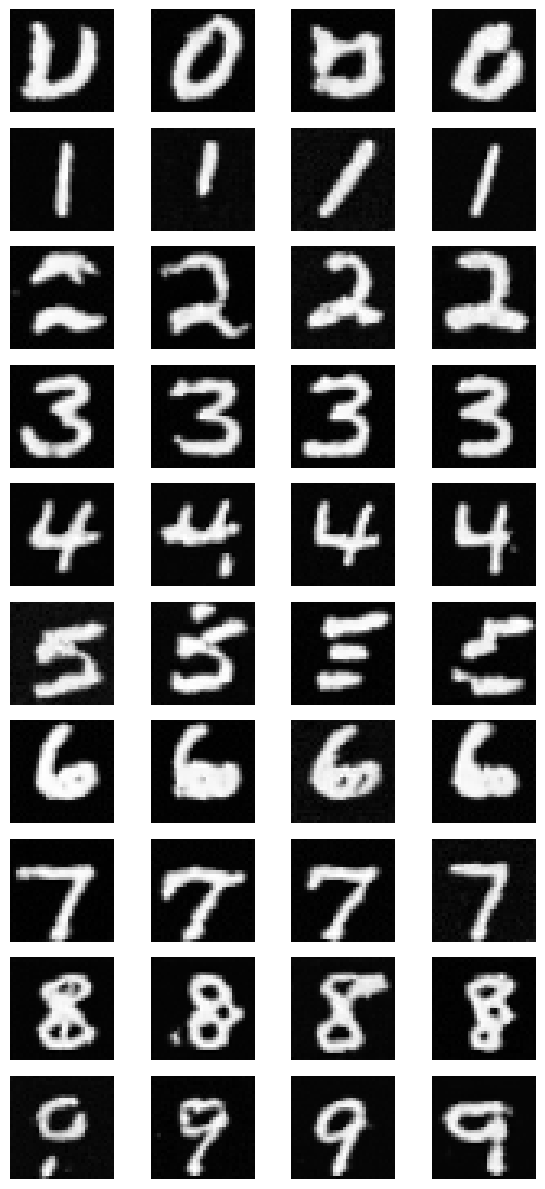

epoch 6 loss 0.1341: 100%|██████████| 938/938 [01:42<00:00,  9.15it/s]


epoch 6 loss 0.12449842691421509
sampling epoch 6


epoch 7 loss 0.1317: 100%|██████████| 938/938 [01:42<00:00,  9.13it/s]


epoch 7 loss 0.10485390573740005
sampling epoch 7


epoch 8 loss 0.1308: 100%|██████████| 938/938 [01:42<00:00,  9.14it/s]


epoch 8 loss 0.1237821877002716
sampling epoch 8


epoch 9 loss 0.1288: 100%|██████████| 938/938 [01:42<00:00,  9.13it/s]


epoch 9 loss 0.12779808044433594
sampling epoch 9


epoch 10 loss 0.1288: 100%|██████████| 938/938 [01:42<00:00,  9.13it/s]


epoch 10 loss 0.117920882999897
sampling epoch 10


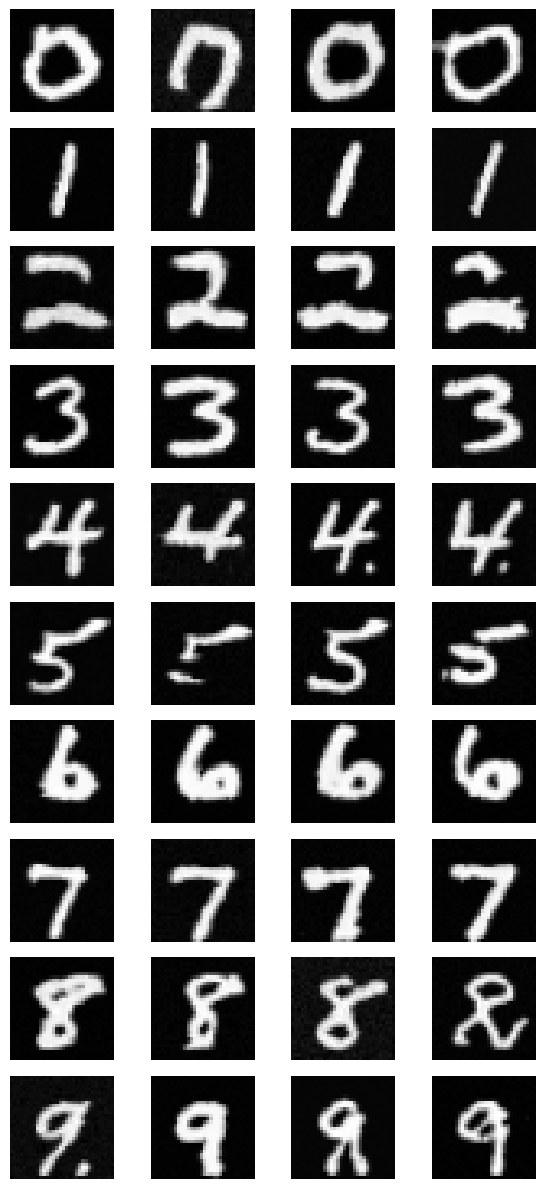

In [34]:
# TODO
model = UNet(
    in_channels=1,
    hidden_dim=32,
    t_dim=64,
    cls_dim=64,
    num_classes=10
).to(device)

flow = FlowMatchingCFG(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
losses = []

for epoch in range(epochs):

    pbar = tqdm(train_loader)

    for x,cls in pbar:

        x = x.to(device)
        cls = cls.to(device)

        loss = flow.loss(x, cls)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        pbar.set_description(f"epoch {epoch+1} loss {sum(losses[-100:])/100:.4f}")

    print("epoch",epoch+1,"loss",loss.item())
    print("sampling epoch",epoch+1)
    if epoch+1 == 1:
      sample_grid(flow, gamma=5.0)

    if epoch+1 == 5:
      sample_grid(flow, gamma=5.0)

    if epoch+1 == 10:
      sample_grid(flow, gamma=5.0)

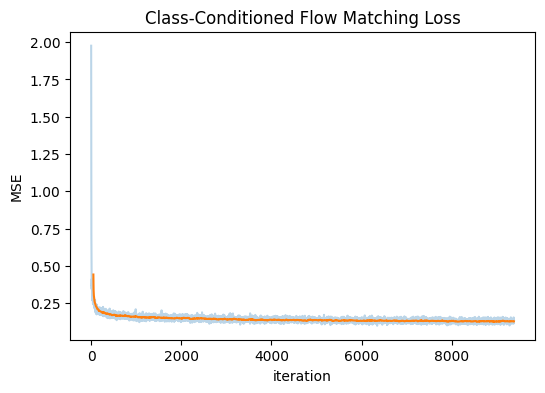

In [35]:
plt.figure(figsize=(6,4))
plt.plot(losses, alpha=0.3)

# moving average
import numpy as np
window = 50
smooth = np.convolve(losses, np.ones(window)/window, mode='valid')

plt.plot(range(window-1, len(losses)), smooth)

plt.title("Class-Conditioned Flow Matching Loss")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.show()